# Impact of Arm Length Variation on Strain Sensitivity

This notebook explores how variations in LISA arm lengths affect the strain sensitivity curves. We compare the sensitivity computed from a nominal orbit (median) against a perturbed orbit with arm length variations. The analysis follows the SEGWO methodology for computing signal and noise covariance matrices and deriving sensitivity curves.

In [1]:
import os
os.environ['PATH'] = "/Users/lorenzo.speri/Library/Application Support/Code/User/globalStorage/github.copilot-chat/debugCommand:/Users/lorenzo.speri/Library/Application Support/Code/User/globalStorage/github.copilot-chat/copilotCli:/opt/miniconda3/envs/fom-contribution/bin:/opt/miniconda3/condabin:/usr/local/bin:/System/Cryptexes/App/usr/bin:/usr/bin:/bin:/usr/sbin:/sbin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/local/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/appleinternal/bin:/opt/pmk/env/global/bin:/Library/Apple/usr/bin:/Library/TeX/texbin:/Users/lorenzo.speri/Library/Application Support/Code/User/globalStorage/github.copilot-chat/debugCommand:/Users/lorenzo.speri/Library/Application Support/Code/User/globalStorage/github.copilot-chat/copilotCli:/Users/lorenzo.speri/.vscode/extensions/ms-python.debugpy-2026.6.0-darwin-arm64/bundled/scripts/noConfigScripts"

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("data/")
plt.rcParams['text.usetex'] = False

from segwo.response import compute_isotropic_signal_cov
from segwo.sensitivity import compute_sensitivity_from_eigenvalues


from lisaconstants import c
from lisaconstants.indexing import LINKS, SPACECRAFT
from pytdi.michelson import X2_ETA, Y2_ETA, Z2_ETA

from segwo_utils import InterpolatedOrbits, ETA_COMBS, noise_list

import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings


plt.rcParams.update()
# ── Publication-quality matplotlib settings ─────────────────────────────────
plt.rcParams.update({
    'text.usetex':       True,        # set True if a LaTeX install is available
    'font.family':       'times',
    'font.size':         9,
    'axes.labelsize':    9,
    'axes.titlesize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'legend.frameon':    True,
    'legend.framealpha': 0.8,
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    ':',
    'lines.linewidth':   1.5,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# ── Figure width constants (inches) ─────────────────────────────────────────
COL1 = 3.5   # single-column
COL2 = 7.2   # double-column


/opt/miniconda3/envs/lisa_resp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
with h5py.File("data/processed_trajectories.h5", "r") as ds:
        t_orb_dataset   = ds["t_interp"][()]
        x_orb_dataset   = ds["spacecraft_positions"][()]
        v_orb_dataset   = ds["spacecraft_velocities"][()]
        ltts_dataset    = ds['owlt_12_23_31_13_32_21'][()]

t_orb        = t_orb_dataset
x_orb        = np.median(x_orb_dataset, axis=0)
v_orb        = np.median(v_orb_dataset, axis=0)
ltts_median  = np.median(ltts_dataset,  axis=0)

In [4]:
test_orbit = InterpolatedOrbits(t_orb, x_orb,
                                spacecraft_velocities=v_orb,
                                ltts=ltts_median,
                                interp_order=3)

test_orbit_waldemar = InterpolatedOrbits(t_orb, x_orb,
                                spacecraft_velocities=v_orb,
                                interp_order=3)
1-test_orbit.compute_ltt([0.0]) / test_orbit_waldemar.compute_ltt([0.0])

array([[ 9.41455824e-09,  1.12677141e-08,  4.43918684e-08,
        -9.24858634e-10,  4.19684341e-08,  2.40584579e-08]])

In [5]:
orbits = InterpolatedOrbits(t_orb, x_orb,
                                spacecraft_velocities=v_orb,
                                ltts=ltts_median,
                                interp_order=3)

perturbed = InterpolatedOrbits(t_orb, x_orb_dataset[1],  # Perturbation of 1 mm in position
                                spacecraft_velocities=v_orb_dataset[1],
                                ltts=ltts_dataset[1],
                                interp_order=3)

In [6]:
array_ltts_sens = np.arange(0,365,15) * 86400.0


## Signal Covariance Matrices

Compute the sky-averaged signal covariance matrices for both nominal and perturbed cases.

In [12]:
import segwo

# Import additional modules needed for SEGWO analysis
from segwo.response import compute_isotropic_signal_cov
from segwo.sensitivity import compute_sensitivity_from_eigenvalues

# Setup frequency grid for sensitivity analysis
f_sens = np.logspace(-4, -2, 50)  # Extended frequency range
f_sens = np.append(f_sens, np.logspace(-2, 0, 500))  # Extended frequency range
f_sens = np.unique(f_sens)  # Remove duplicates

# Recompute orbits with higher time resolution for sensitivity analysis
# array_ltts_sens = np.linspace(0, 365, num=50) * 86400.0  # 50 time points

ltts_sens      = orbits.compute_ltt(t=array_ltts_sens)
positions_sens = orbits.compute_position(t=array_ltts_sens)

ltts_sens_perturbed      = perturbed.compute_ltt(t=array_ltts_sens)
positions_sens_perturbed = perturbed.compute_position(t=array_ltts_sens)

print(f"LTTs shape (nominal): {ltts_sens.shape}")
print(f"LTTs shape (perturbed): {ltts_sens_perturbed.shape}")

LTTs shape (nominal): (25, 6)
LTTs shape (perturbed): (25, 6)


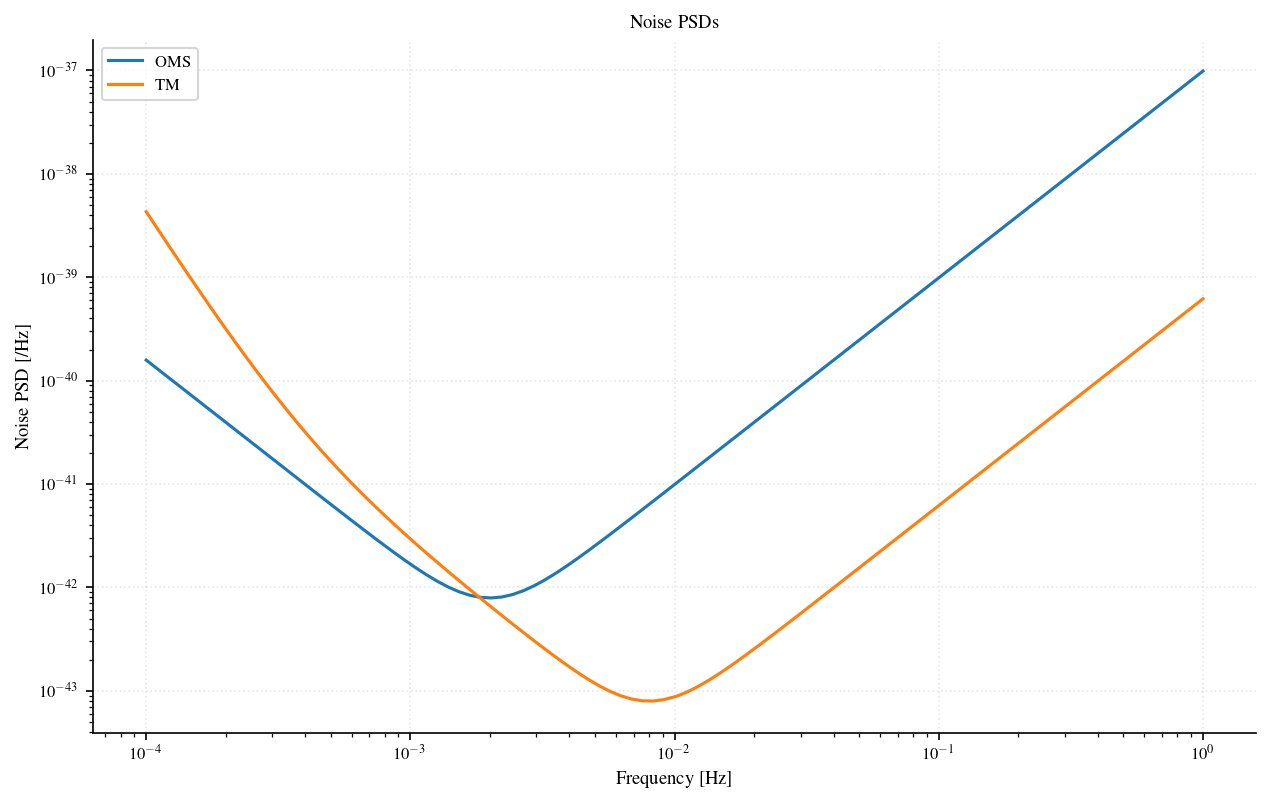

(549, 12, 12)

In [13]:
# Define the noise PSDs, using LISA SciRD noise levels and shapes

# The OMS noise is defined in terms of displacement (meters), which we convert
# to fractional frequency shifts
displ_2_ffd = 2 * np.pi * f_sens / c
oms = (15e-12) ** 2 * displ_2_ffd**2 * (1 + ((2e-3) / f_sens) ** 4)

# The TM noise is defined in terms of acceleration (m/s^2), which we convert to
# fractional frequency shifts
acc_2_ffd = 1 / (2 * np.pi * f_sens * c)
tm = (3e-15) ** 2 * acc_2_ffd**2 * (1 + (0.4e-3 / f_sens) ** 2) * (1 + (f_sens / 8e-3) ** 4)

noise_cov = segwo.cov.construct_covariance_from_psds([oms] * 6 + [tm] * 6)

# Plot the noise PSDs
# As expected, the OMS noise is much larger dominates at high frequencies, while
# the TM noise dominates at low frequencies (below ~ 1 mHz)
plt.figure(figsize=(10, 6))
plt.loglog(f_sens, oms, label="OMS")
plt.loglog(f_sens, tm, label="TM")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Noise PSD [/Hz]")
plt.title("Noise PSDs")
plt.legend()
plt.show()

noise_cov.shape

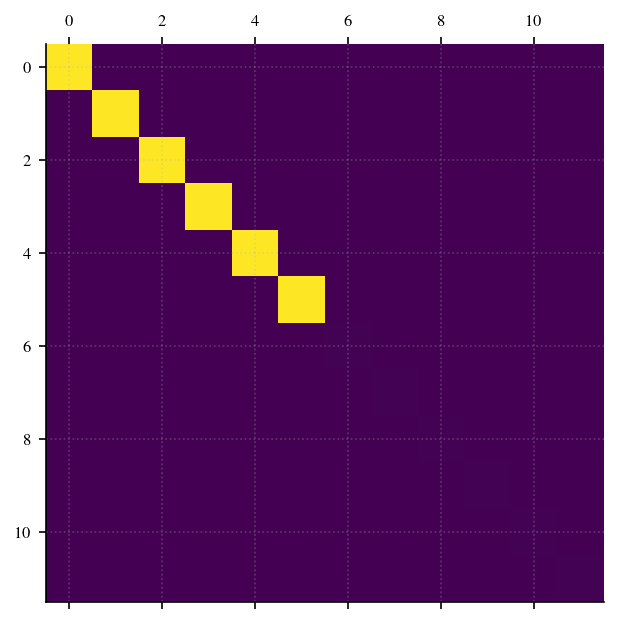

In [14]:
plt.matshow(noise_cov[80])
# np.array(noise_cov[10])

## Noise Covariance and Mixing Matrices

Setup the noise transfer functions and compute noise covariance matrices following the SEGWO tutorial.

## Sensitivity Computation

Compute optimal sensitivity curves using the signal and noise covariance matrices.

In [15]:
def compute_sensitivity_from_orbits(orbit, f_grid, time_points, noise_cov):
    """
    Compute strain sensitivity from orbit object.
    
    Parameters
    ----------
    orbit : InterpolatedOrbits
        Orbit object containing spacecraft positions and light travel times
    f_grid : ndarray
        Frequency grid [Hz]
    time_points : ndarray
        Time points for orbit evaluation [s]
    noise_cov : ndarray
        Noise covariance matrix (precomputed)
    
    Returns
    -------
    sensitivity_xyz : ndarray
        Optimal sensitivity in XYZ observables
    signal_cov_xyz : ndarray
        Signal covariance in XYZ
    noise_cov_xyz : ndarray
        Noise covariance in XYZ
    """

    # Compute light travel times and positions
    ltts = orbit.compute_ltt(t=time_points)
    positions = orbit.compute_position(t=time_points)
    
    # Compute signal covariance for single links
    signal_cov_eta = compute_isotropic_signal_cov(f_grid, ltts, positions)
    # print(f"Signal covariance shape (eta): {signal_cov_eta.shape}")
    # signal_cov_eta_avg = signal_cov_eta.mean(axis=0, keepdims=True)
    
    # Define eta labels for TDI combinations
    eta_list = [f"eta_{mosa}" for mosa in LINKS]
    
    # Construct mixing matrices using precomputed ETA_COMBS and noise_list from segwo_utils
    noise2eta = segwo.cov.construct_mixing_from_pytdi(
        f_grid,
        measurements=noise_list,
        tdi_combinations=[ETA_COMBS[mosa] for mosa in LINKS],
        ltts=ltts,
    )
    
    eta2xyz = segwo.cov.construct_mixing_from_pytdi(
        f_grid, eta_list, [X2_ETA, Y2_ETA, Z2_ETA], ltts
    )
    
    # Project signal covariance to XYZ
    signal_cov_xyz = segwo.cov.project_covariance(signal_cov_eta, eta2xyz)
    
    # Project noise covariance to XYZ
    noise_cov_xyz = segwo.cov.project_covariance(noise_cov, [noise2eta, eta2xyz])
    
    # Compute sensitivity
    sensitivity_xyz = compute_sensitivity_from_eigenvalues(
        noise_cov_xyz, signal_cov_xyz
    )
    
    return sensitivity_xyz, signal_cov_xyz, noise_cov_xyz


print("Function 'compute_sensitivity_from_orbits' defined")

Function 'compute_sensitivity_from_orbits' defined


In [16]:
# Compute sensitivity for nominal orbits using the function
print("Computing sensitivity for nominal orbits...")
sensitivity_nominal, signal_cov_xyz_nominal, noise_cov_xyz_nominal = compute_sensitivity_from_orbits(
    orbits, f_sens, array_ltts_sens, noise_cov
)

# Compute sensitivity for perturbed orbits using the function
print("Computing sensitivity for perturbed orbits...")
sensitivity_perturbed, signal_cov_xyz_perturbed, noise_cov_xyz_perturbed = compute_sensitivity_from_orbits(
    perturbed, f_sens, array_ltts_sens, noise_cov
)

print(f"Sensitivity curves computed:")
print(f"  nominal shape: {sensitivity_nominal.shape}")
print(f"  perturbed shape: {sensitivity_perturbed.shape}")

# Also compute individual channel sensitivities
sensitivity_x_nominal = segwo.sensitivity.compute_single_channel_sensitivities(
    np.diagonal(noise_cov_xyz_nominal, axis1=-2, axis2=-1), signal_cov_xyz_nominal, 
    # channels=[0]
)

sensitivity_x_perturbed = segwo.sensitivity.compute_single_channel_sensitivities(
    np.diagonal(noise_cov_xyz_perturbed, axis1=-2, axis2=-1), signal_cov_xyz_perturbed, 
    # channels=[0]
)

print("X-channel sensitivities computed")

Computing sensitivity for nominal orbits...
Computing sensitivity for perturbed orbits...
Sensitivity curves computed:
  nominal shape: (25, 549)
  perturbed shape: (25, 549)
X-channel sensitivities computed


In [17]:
sensitivity_nominal.shape

(25, 549)

## Impact Analysis: Sensitivity Comparison

Compare the strain sensitivity curves between nominal and perturbed arm lengths.

In [18]:
sensitivity_x_perturbed.shape

(25, 549, 3)

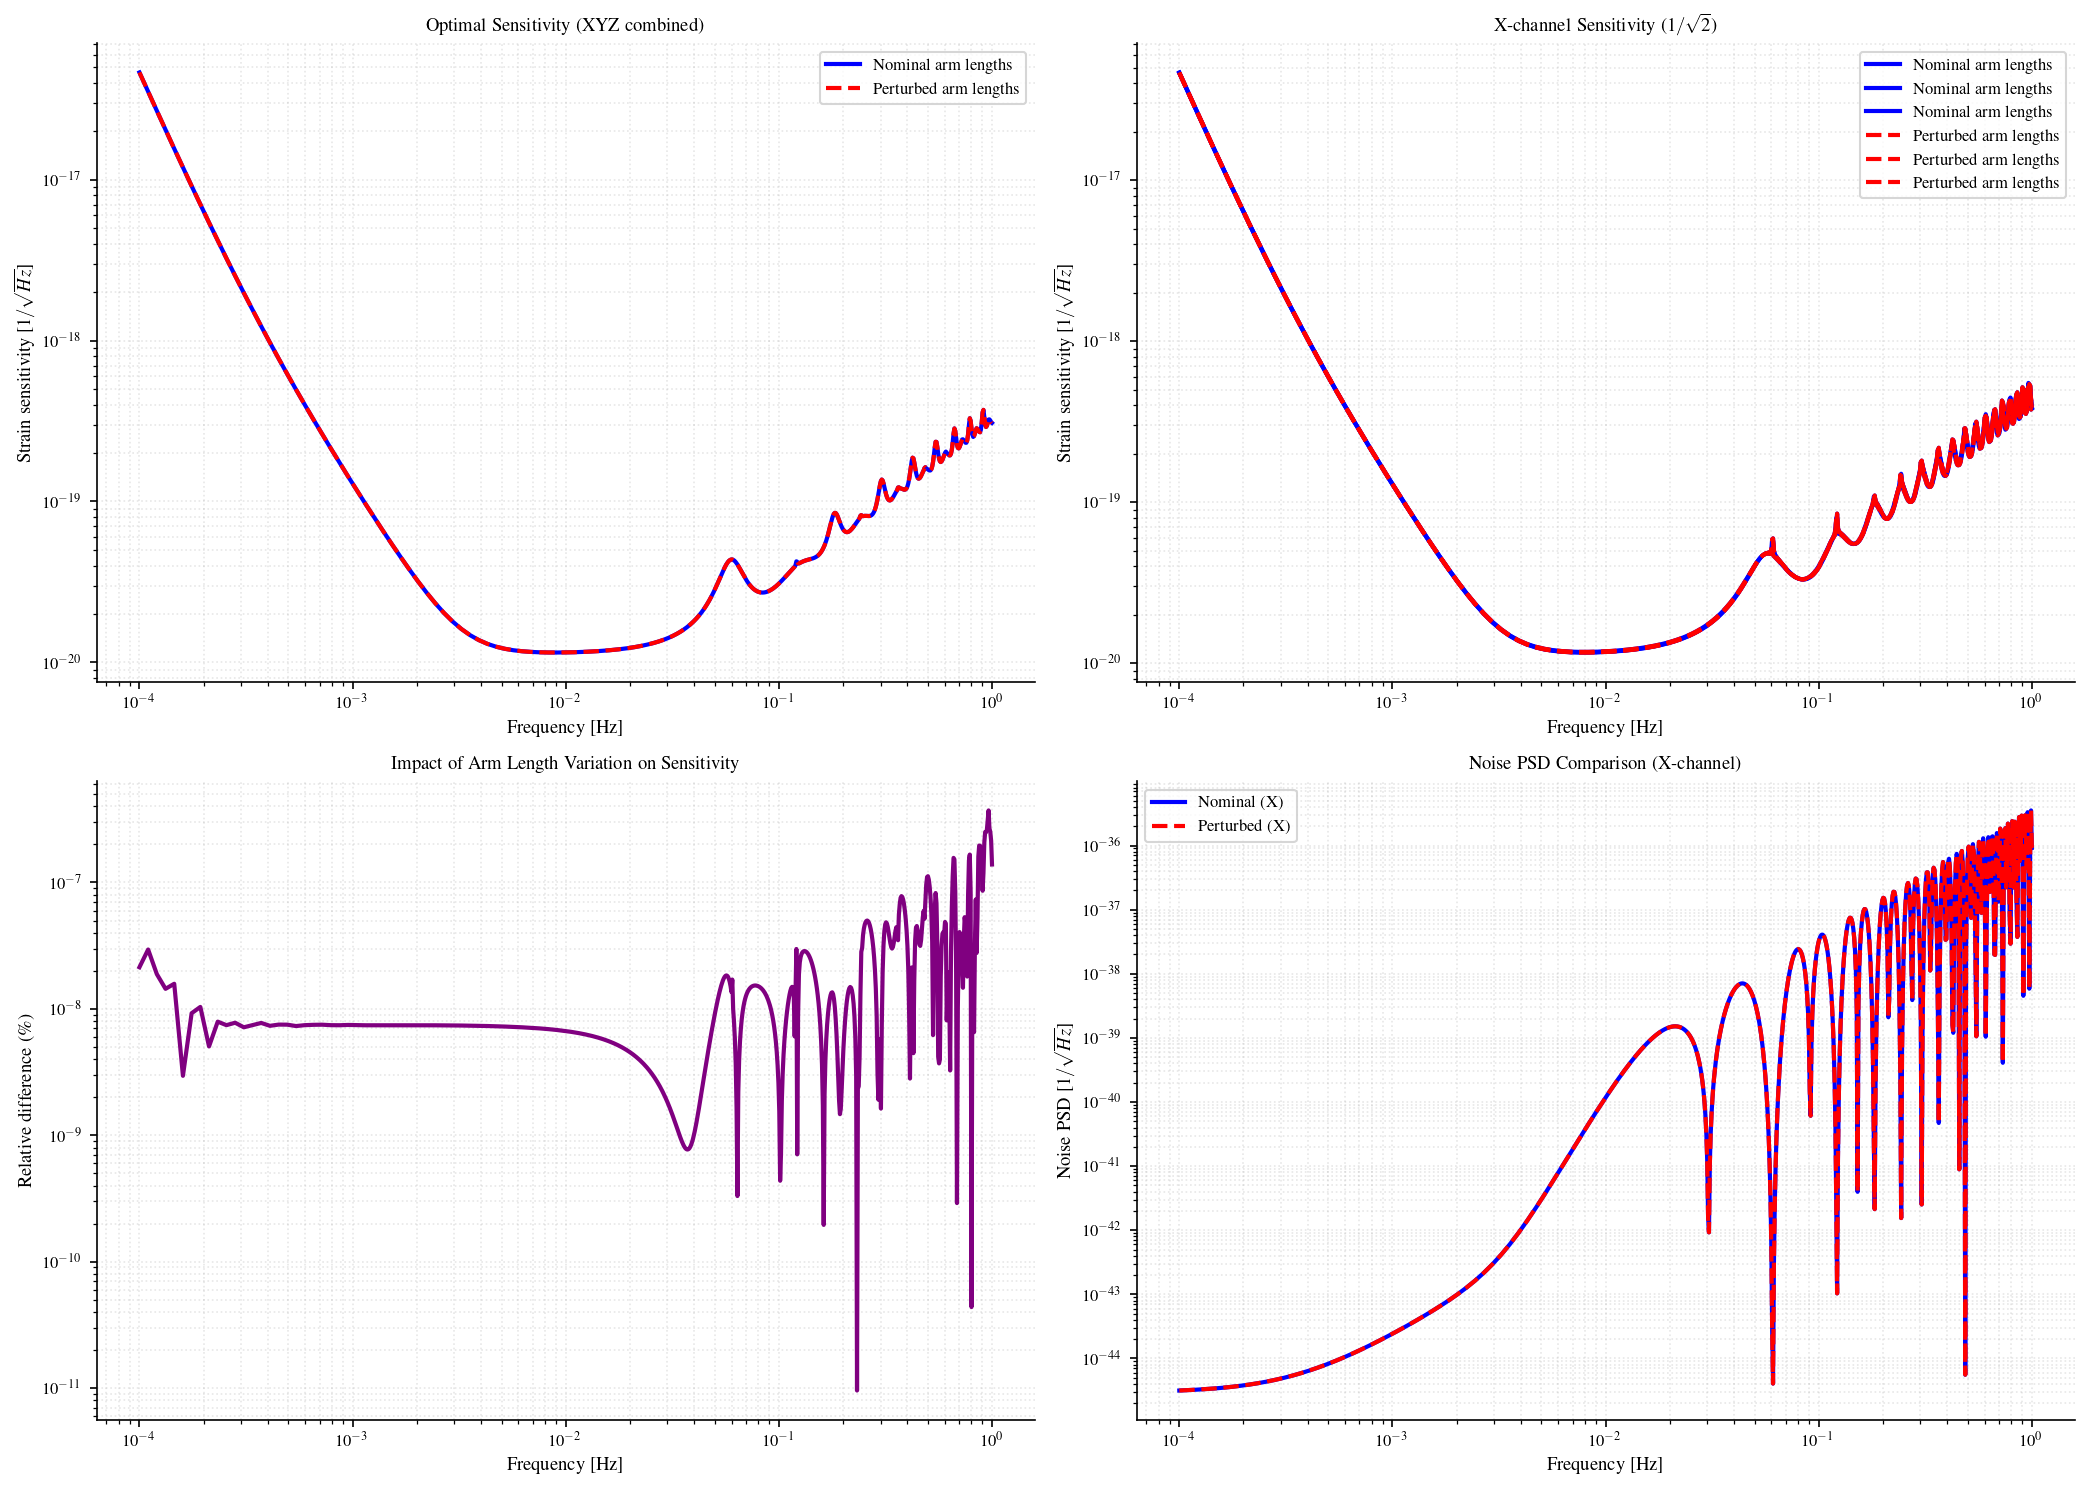

Comparison plots generated


In [22]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Optimal sensitivity comparison
ax = axes[0, 0]
ax.loglog(f_sens, np.sqrt(sensitivity_nominal[0]), 'b-', linewidth=2, label='Nominal arm lengths')
ax.loglog(f_sens, np.sqrt(sensitivity_perturbed[0]), 'r--', linewidth=2, label='Perturbed arm lengths')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Strain sensitivity [$1/\sqrt{Hz}$]')
ax.set_title('Optimal Sensitivity (XYZ combined)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

# Plot 2: X-channel sensitivity comparison
ax = axes[0, 1]
ax.loglog(f_sens, np.sqrt(sensitivity_x_nominal[0] / 2), 'b-', linewidth=2, label='Nominal arm lengths')
ax.loglog(f_sens, np.sqrt(sensitivity_x_perturbed[0] / 2), 'r--', linewidth=2, label='Perturbed arm lengths')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Strain sensitivity [$1/\sqrt{Hz}$]')
ax.set_title('X-channel Sensitivity ($1/\sqrt{2}$)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

# Plot 3: Relative difference in sensitivity
ax = axes[1, 0]
relative_diff = np.abs(np.sqrt(sensitivity_perturbed[0]) - np.sqrt(sensitivity_nominal[0])) / np.sqrt(sensitivity_nominal[0]) * 100
ax.loglog(f_sens, relative_diff, 'purple', linewidth=2)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Relative difference ($\%$)')
ax.set_title('Impact of Arm Length Variation on Sensitivity')
ax.grid(True, which='both', alpha=0.3)

# Plot 4: Noise covariance comparison (diagonal elements in X)
ax = axes[1, 1]
ax.loglog(f_sens, np.abs(noise_cov_xyz_nominal[0, :, 0, 0]), 'b-', linewidth=2, label='Nominal (X)')
ax.loglog(f_sens, np.abs(noise_cov_xyz_perturbed[0, :, 0, 0]), 'r--', linewidth=2, label='Perturbed (X)')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Noise PSD [$1/\sqrt{Hz}$]')
ax.set_title('Noise PSD Comparison (X-channel)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

print("Comparison plots generated")

In [23]:
relative_change_ltt_1_sigma = np.std(ltts_sens,axis=0)/np.mean(ltts_sens,axis=0)
relative_change_ltt_1_sigma

array([0.0087637 , 0.00444222, 0.00705764, 0.00718579, 0.0043191 ,
       0.0086444 ])

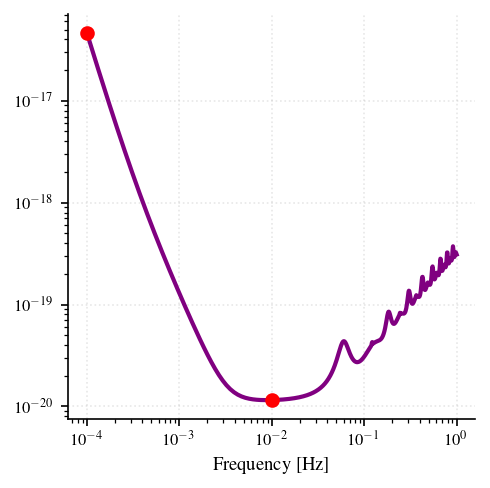

In [24]:
fig, ax          = plt.subplots(figsize=(COL1, COL1))
ax.loglog(f_sens, np.sqrt(sensitivity_nominal[2]), 'purple', linewidth=2)
ax.plot(1e-4, (2.11e-33)**0.5, 'ro')
ax.plot(1e-2, (1.359e-40)**0.5, 'ro')
ax.set_xlabel('Frequency [Hz]')
plt.show()


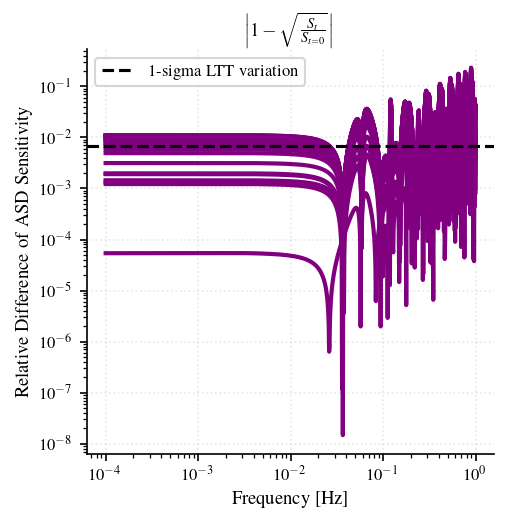

In [25]:
fig, ax          = plt.subplots(figsize=(COL1, COL1))
ax.loglog(f_sens, np.abs(1-np.sqrt(sensitivity_nominal/sensitivity_nominal[0])).T, 'purple', linewidth=2)
ax.set_xlabel('Frequency [Hz]')
ax.set_title(r'$\left|1 - \sqrt{\frac{S_{t}}{S_{t=0}}}\right|$')
ax.set_ylabel('Relative Difference of ASD Sensitivity')
ax.axhline(relative_change_ltt_1_sigma.mean(), color='k', linestyle='--', label='1-sigma LTT variation')
ax.legend()
plt.savefig("paper_plots/sensitivity_relative_difference_asd.png", dpi=300)
plt.show()

In [26]:
relative_change_breathing = np.max(np.std(ltts_sens,axis=0)/np.mean(ltts_sens,axis=0))
relative_change_ltt_pert = np.max(np.abs(ltts_sens-ltts_sens_perturbed)[:1]/ltts_sens[:1])

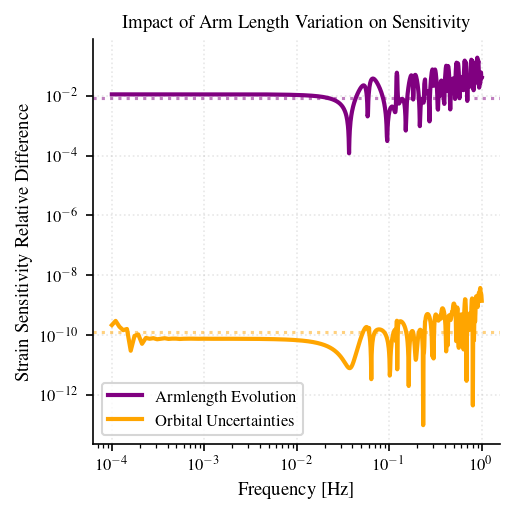

In [27]:
fig, ax = plt.subplots(figsize=(COL1, COL1))
relative_diff_breathing = np.max(np.abs(np.sqrt(sensitivity_perturbed[:]) - np.sqrt(sensitivity_perturbed[0])) / np.sqrt(sensitivity_perturbed[:]),axis=0)
relative_diff_ltt_pert = np.abs((np.sqrt(sensitivity_perturbed[:1]) - np.sqrt(sensitivity_nominal[0])) / np.sqrt(sensitivity_nominal[0])).max(axis=0)
ax.loglog(f_sens, relative_diff_breathing, 'purple', linewidth=2)
ax.loglog(f_sens, relative_diff_ltt_pert, 'orange', linewidth=2)
# ax.axhline(y=0.1, color='k', linestyle='--', alpha=0.3, label='10\% threshold')
ax.axhline(y=relative_change_breathing, color='purple', linestyle=':', alpha=0.5, label='LTT armlength evolution')
ax.axhline(y=relative_change_ltt_pert, color='orange', linestyle=':', alpha=0.5, label='LTT orbital uncertainties')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Strain Sensitivity Relative Difference')
ax.set_title('Impact of Arm Length Variation on Sensitivity')
# ax.grid(True, which='both', alpha=0.3)
ax.legend(['Armlength Evolution','Orbital Uncertainties', ])
plt.savefig("paper_plots/sensitivity_relative_difference.png", dpi=300)
plt.show()

In [20]:
signal_cov_xyz_perturbed.shape

(25, 249, 3, 3)

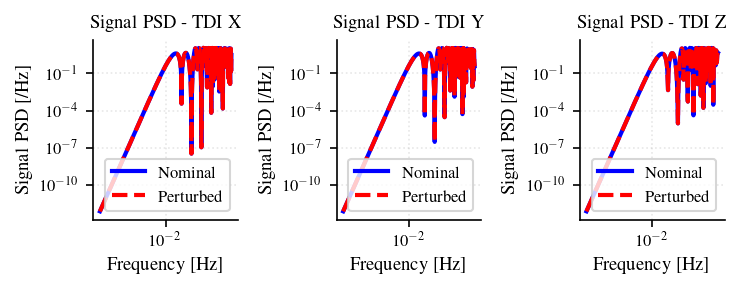

Signal and noise covariance comparison plots generated


In [21]:
# Create detailed plots of signal and noise covariances

TDI_LABELS = ["X", "Y", "Z"]

fig, axes = plt.subplots(1, 3, figsize=(5, 2))

# Plot signal PSDs for each TDI channel
for i, tdi in enumerate(TDI_LABELS):
    ax = axes[i]
    ax.loglog(f_sens, np.abs(signal_cov_xyz_nominal[0, :, i, i]), 'b-', linewidth=2, label='Nominal')
    ax.loglog(f_sens, np.abs(signal_cov_xyz_perturbed[0, :, i, i]), 'r--', linewidth=2, label='Perturbed')
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('Signal PSD [/Hz]')
    ax.set_title(f'Signal PSD - TDI {tdi}')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)


plt.tight_layout()
plt.show()

print("Signal and noise covariance comparison plots generated")

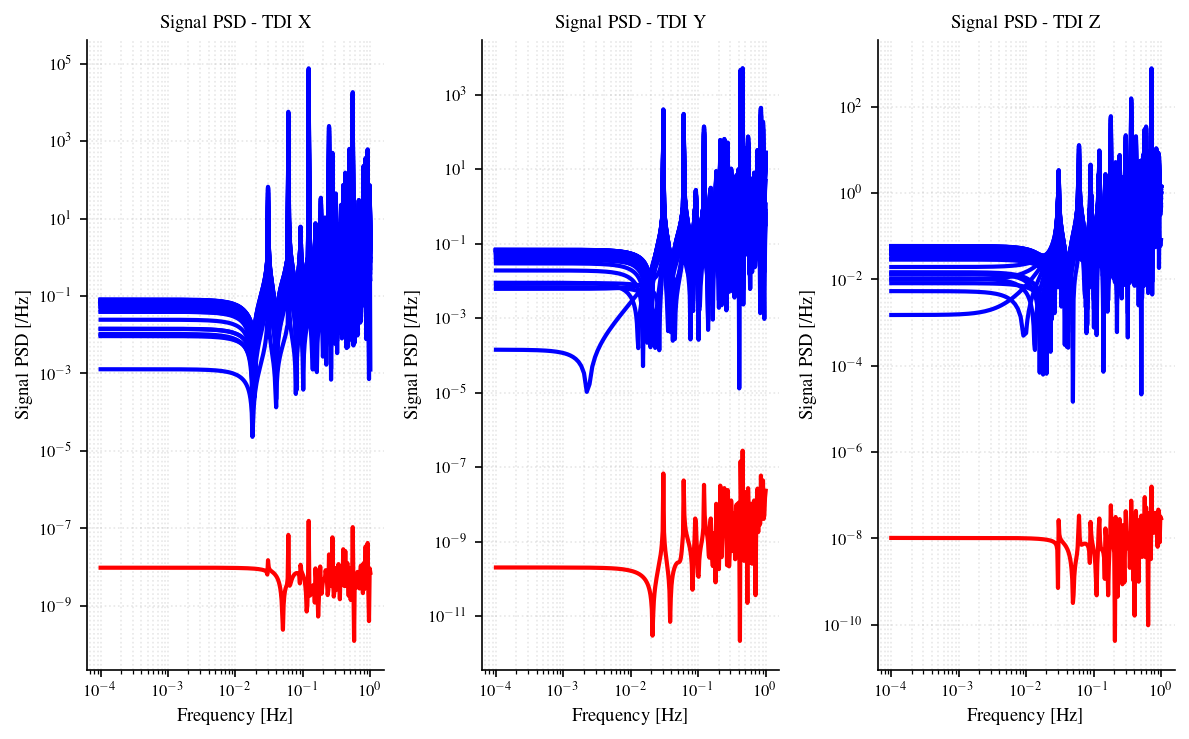

Signal and noise covariance comparison plots generated


In [23]:
# Create detailed plots of signal and noise covariances

TDI_LABELS = ["X", "Y", "Z"]

fig, axes = plt.subplots(1, 3, figsize=(8, 5))

# Plot signal PSDs for each TDI channel
for i, tdi in enumerate(TDI_LABELS):
    ax = axes[i]
    ax.loglog(f_sens, np.abs(1-np.abs(signal_cov_xyz_perturbed[:, :, i, i])/np.abs(signal_cov_xyz_perturbed[0, :, i, i])).T, 'b-', linewidth=2)
    ax.loglog(f_sens, np.abs(1-np.abs(signal_cov_xyz_nominal[0, :, i, i])/np.abs(signal_cov_xyz_perturbed[0, :, i, i])).T, 'r-', linewidth=2)
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('Signal PSD [/Hz]')
    ax.set_title(f'Signal PSD - TDI {tdi}')
    ax.grid(True, which='both', alpha=0.3)


plt.tight_layout()
plt.show()

print("Signal and noise covariance comparison plots generated")